# Lab Report for the CAT vs DOG training example
The general idea in this report is to start with a baseline example, given to everyone as a starting point.
We primarily look at the training/validation loss/accuracy data over epochs and gradually extend the model and training to reach increasingly better accuracy. Finally we test the model prediction on a small number of images not part of the training or validation.

## Baseline Example
The baseline example shows early signs of overfitting.

- Already around epoch 5 training and validation losses/accuracy starts to deviate
- Validation accuracy does not reach above 70%

In [3]:
import lab2_baseline
history=lab2_baseline.run()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


/home/alek/miniconda3/envs/cuda/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,178 (10.22 MB)

 Trainable params: 2,678,178 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


2025-11-08 19:52:10.165225: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 19:52:10.333432: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_342', 20 bytes spill stores, 20 bytes spill loads

2025-11-08 19:52:10.777416: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_668', 520 bytes spill stores, 520 bytes spill loads



63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.5405 - loss: 0.7355 - val_accuracy: 0.6170 - val_loss: 0.6628
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6480 - loss: 0.6292 - val_accuracy: 0.6690 - val_loss: 0.6078
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7130 - loss: 0.5701 - val_accuracy: 0.6790 - val_loss: 0.6186
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7620 - loss: 0.4903 - val_accuracy: 0.6780 - val_loss: 0.6125
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8085 - loss: 0.4204 - val_accuracy: 0.6700 - val_loss: 0.7774
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8425 - loss: 0.3533 - val_accuracy: 0.7050 - val_loss: 0.7162
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9100 - loss: 0.2385 - val_accuracy: 0.7150 - val_loss: 0.8135
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9405 - loss: 0.1655 - val_accuracy: 0.7110 - val_loss: 0

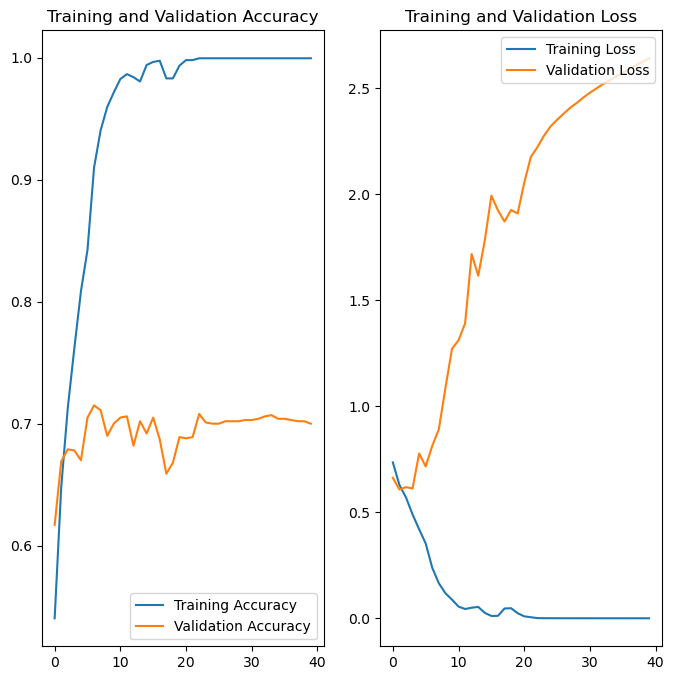

In [4]:
lab2_baseline.plot(history)

## Basic Improvements of Baseline
In a first attempt we try to improve the model by

- Adding more convolutional layers
- Adding more pooling that reduces the dimensions of later layers
- Increasing number or neurons in main Dense layer
- Adding Dropout to dense layers
- Changing optimizer to rmsprop

The result shows the following improvements

- Signs of overfitting now at 10-15 epoch instead of 5
- The maximum validation accuracy is now up to about 80% instead of 70%

We still have clear signs of overfitting.

In [5]:
import lab2_baseline_basic_improvements
history_1=lab2_baseline_basic_improvements.run()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,291,874 (24.00 MB)

 Trainable params: 6,291,874 (24.00 MB)

...

Epoch 1/40


2025-11-08 19:53:36.781036: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-08 19:53:37.266025: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1123', 24 bytes spill stores, 24 bytes spill loads

2025-11-08 19:53:37.437243: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1123', 520 bytes spill stores, 520 bytes spill loads



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5084 - loss: 0.7920

2025-11-08 19:53:45.126768: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_140', 16 bytes spill stores, 16 bytes spill loads



63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.5060 - loss: 0.7348 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4960 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5190 - loss: 0.6962 - val_accuracy: 0.5550 - val_loss: 0.6891
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5490 - loss: 0.6889 - val_accuracy: 0.5350 - val_loss: 0.6746
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5915 - loss: 0.6768 - val_accuracy: 0.6000 - val_loss: 0.6652
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6160 - loss: 0.6555 - val_accuracy: 0.6420 - val_loss: 0.6358
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6355 - loss: 0.6370 - val_accuracy: 0.5890 - val_loss: 0.6933
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6545 - loss: 0.6248 - val_accuracy: 0.6610 - val_loss: 

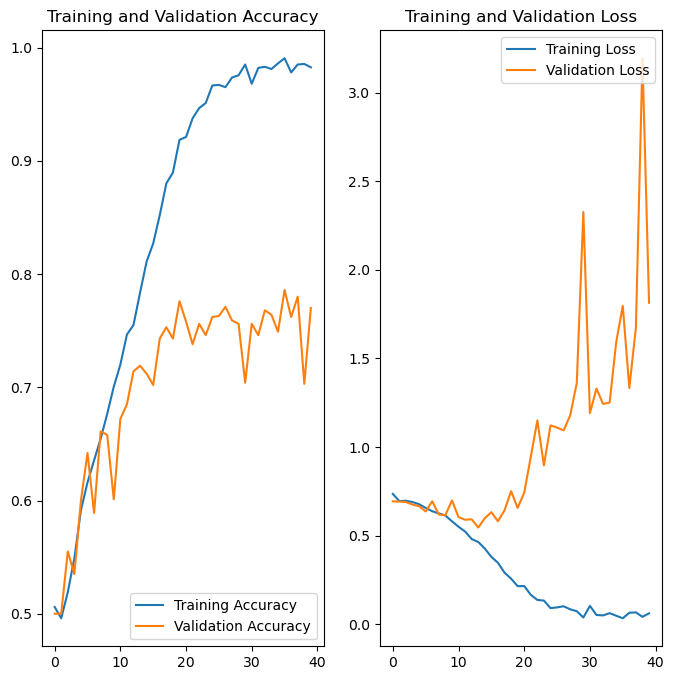

In [6]:
lab2_baseline_basic_improvements.plot(history_1)

## Adding image augmentation

To combat the clear overfitting problems, we add a preprocessing step for input data where
various transformations are applied to the original dataset to create enough model training data
to prevent divergence of training and validation training losses.

The results show 

- Training and validation losses/accuracy now follow each other more closely
- There has been a slight loss in maximum accuracy from 80% to about 75%

In [7]:
import lab2_baseline_augmentation
history_2 = lab2_baseline_augmentation.run()

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/home/alek/miniconda3/envs/cuda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,291,874 (24.00 MB)

...

 Non-trainable params: 0 (0.00 B)

/home/alek/miniconda3/envs/cuda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5035 - loss: 0.6932

/home/alek/miniconda3/envs/cuda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step - accuracy: 0.4860 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.4950 - loss: 0.6939 - val_accuracy: 0.5250 - val_loss: 0.6931
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.4980 - loss: 0.6944 - val_accuracy: 0.5010 - val_loss: 0.6930
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.5010 - loss: 0.7019 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.5095 - loss: 0.6932 - val_accuracy: 0.5130 - val_loss: 0.6924
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.5615 - loss: 0.6969 - val_accuracy: 0.5510 - val_loss: 0.6849
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.5290 - loss: 0.6916 - val_accuracy: 0.5630 - val_loss: 0.6865
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.5595 - loss: 0.6863 - val_accuracy: 0.502

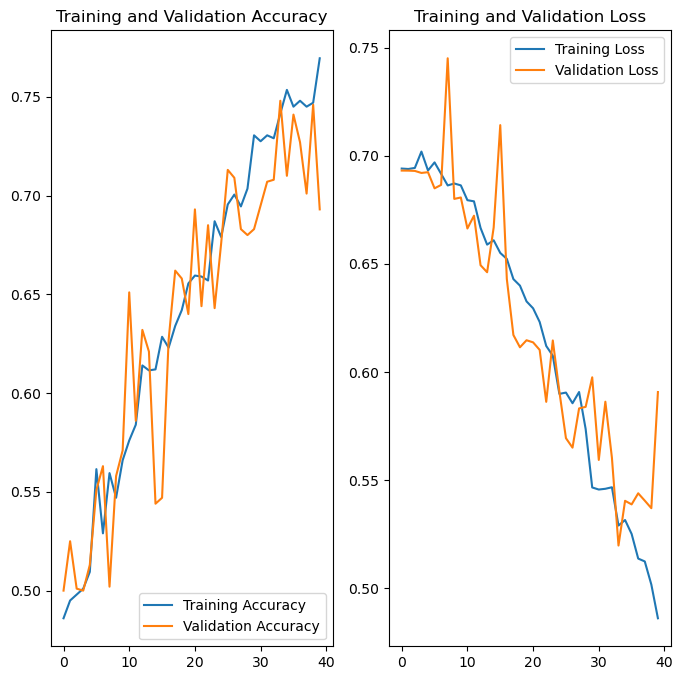

In [8]:
lab2_baseline_augmentation.plot(history_2)

## Final Model
In order to step up the model accuracy we re-use a larger model pre-trained on a much larger image dataset. Since these are convolutional models, we anticipate that the convolutional parts will be transferrable. We then add our own dense layers to fine tune to our dataset.

The result shows

- Much higher maximum validation accuracy of about 94%
- Beyond epoch 10 there is a little bit of divergence between training and validation data, but I kept the 40 epoch limit to generate more easily comparable results in this report. 


In [9]:
import lab2_baseline_add_pretrained_model
history_3 = lab2_baseline_add_pretrained_model.run()

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 74, 74,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │         96 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 72, 72,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │         96 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 72, 72,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │        192 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 35, 35,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 35, 35,    │      5,120 │ max_pooling2d_11… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        240 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 33, 33,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │        576 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 33, 33,    │          0 │ batch_normalizat

 Total params: 47,513,506 (181.25 MB)

 Trainable params: 38,538,242 (147.01 MB)

...

39/63 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.6920 - loss: 2.6413

2025-11-08 20:02:47.219030: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 341.07MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-08 20:02:47.590382: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 552.78MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7381 - loss: 2.0492

2025-11-08 20:03:00.016288: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1902', 12 bytes spill stores, 12 bytes spill loads

2025-11-08 20:03:00.810873: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 308.57MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-08 20:03:01.080397: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 532.15MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.8275 - loss: 0.9216 - val_accuracy: 0.9190 - val_loss: 0.1916
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9275 - loss: 0.1887 - val_accuracy: 0.9000 - val_loss: 0.2459
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9350 - loss: 0.1603 - val_accuracy: 0.9320 - val_loss: 0.1727
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9410 - loss: 0.1599 - val_accuracy: 0.9310 - val_loss: 0.1677
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9390 - loss: 0.1461 - val_accuracy: 0.9120 - val_loss: 0.2108
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9470 - loss: 0.1460 - val_accuracy: 0.9100 - val_loss: 0.2228
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9310 - loss: 0.1663 - val_accuracy: 0.9110 - val_loss: 0.2222
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9460 - loss: 0.1439 - val_accuracy: 0.927

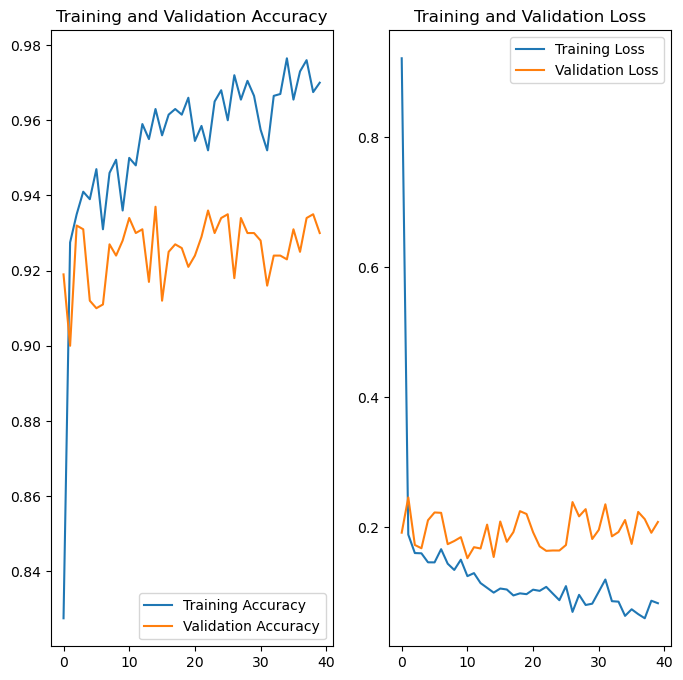

In [10]:
lab2_baseline_add_pretrained_model.plot(history_3)

## Final Test
Finally, we test our network on a few image samples from the internet. The correct classification is

- test/mypet.jpg [CAT]
- test/cat_1.jpg [CAT]
- test/cat_2.jpg [CAT]
- test/dog_1.jpg [DOG]
- test/dog_2.jph [DOG]

The results looks good! There are some CUDA errors involved throughout the calcuations. These should be looked into, but it is out of the scope of this report.

In [1]:
%run lab2_test.py

2025-11-08 20:12:39.703113: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 20:12:39.776429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-08 20:12:40.716841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1762629161.458751  128727 gpu_device.cc:2020] Created device /job:localhost/rep

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Test image evaluation:  [[ 10.1037   -10.324454]]
Test test/mypet.jpg is of category: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Test image evaluation:  [[ 0.46464366 -1.6932331 ]]
Test test/cat_1.jpg is of category: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test image evaluation:  [[ 10.076664 -10.164883]]
Test test/cat_2.jpg is of category: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

I0000 00:00:1762629170.562036  128798 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test image evaluation:  [[-8.677449   5.8868594]]
Test test/dog_1.jpg is of category: dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Test image evaluation:  [[-7.790904   5.1714025]]
Test test/dog_2.jpg is of category: dog
